# 🌫️ AQI Prediction — Full Analysis Notebook

**Course Project** | Air Quality Index Prediction using Machine Learning

> Predicts AQI values for Indian cities using **Random Forest** and **CatBoost** regressors.  
> Applies **BeautifulSoup** scraping, **pandas/numpy** preprocessing, and **SMOTE** for class balancing.

---
### Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Overview](#2-data-loading--overview)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis)
4. [Preprocessing & Feature Engineering](#4-preprocessing--feature-engineering)
5. [SMOTE — Handling Class Imbalance](#5-smote--handling-class-imbalance)
6. [Model Training](#6-model-training)
7. [Model Evaluation](#7-model-evaluation)
8. [Feature Importance](#8-feature-importance)
9. [Predictions vs Actual](#9-predictions-vs-actual)
10. [Summary](#10-summary)


## 1. Setup & Imports

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # allow imports from project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from catboost import CatBoostRegressor

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
sns.set_palette("muted")
print("✅ All libraries loaded successfully")


✅ All libraries loaded successfully


## 2. Data Loading & Overview

In [2]:
# Load dataset (generated by scraper/aqi_scraper.py)
df = pd.read_csv("../data/aqi_raw.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)


Dataset shape: (500, 14)
Columns: ['city', 'pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3', 'nh3', 'temperature', 'humidity', 'wind_speed', 'month', 'aqi', 'aqi_category']


,city,pm2_5,pm10,no2,so2,co,o3,nh3,temperature,humidity,wind_speed,month,aqi,aqi_category
0,delhi,118.616634,285.301451,26.290287,42.488379,2.690886,150.678217,33.962447,20.028184,62.899691,17.978979,3,169.5,Poor
1,mumbai,285.707149,223.716619,67.318609,39.376186,2.545090,139.969725,40.037388,38.092411,80.407425,15.411236,8,227.1,Very Poor
2,kolkata,222.278243,137.620494,105.388771,4.000081,9.071920,107.499922,13.272927,44.903326,77.012070,8.645536,7,152.7,Poor
3,chennai,183.610960,329.242107,89.205862,28.617331,2.570507,172.528014,31.618831,11.050910,31.542493,0.193931,3,173.2,Poor
4,bengaluru,55.245406,280.197846,97.754532,31.655258,2.792302,44.080668,29.015553,41.407805,31.193710,14.887177,6,115.6,Moderate
5,hyderabad,55.238411,81.794437,80.760087,33.108177,7.618043,28.574916,41.808688,31.792069,40.113078,8.568780,4,85.9,Satisfactory
6,ahmedabad,26.844248,366.152330,84.611805,47.253445,4.552424,155.173534,45.398266,44.068392,47.080604,22.038249,11,165.7,Poor
7,pune,261.191082,332.564152,102.657500,43.620999,7.789435,84.655469,1.595682,26.275333,50.634169,0.718388,5,244.4,Very Poor
8,jaipur,184.323353,380.923967,33.711821,49.416597,0.747125,153.984705,34.026976,39.658578,70.977291,17.544834,11,192.1,Poor
9,lucknow,215.341048,295.773413,61.283871,61.660894,4.926955,161.825335,3.539954,12.183792,24.251032,28.244227,5,199.0,Poor


In [3]:
# Basic info & missing values
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          500 non-null    str    
 1   pm2_5         500 non-null    float64
 2   pm10          500 non-null    float64
 3   no2           500 non-null    float64
 4   so2           500 non-null    float64
 5   co            500 non-null    float64
 6   o3            500 non-null    float64
 7   nh3           500 non-null    float64
 8   temperature   500 non-null    float64
 9   humidity      500 non-null    float64
 10  wind_speed    500 non-null    float64
 11  month         500 non-null    int64  
 12  aqi           500 non-null    float64
 13  aqi_category  500 non-null    str    
dtypes: float64(11), int64(1), str(2)
memory usage: 54.8 KB

Missing values per column:
city            0
pm2_5           0
pm10            0
no2             0
so2             0
co              0
o3       

In [4]:
# Statistical summary
df.describe().round(2)


,pm2_5,pm10,no2,so2,co,o3,nh3,temperature,humidity,wind_speed,month,aqi
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,154.58,203.14,64.52,40.73,5.05,95.84,25.39,26.90,56.55,15.03,6.62,149.45
std,86.62,108.49,34.18,22.39,2.83,50.27,13.87,10.15,21.21,8.73,3.38,58.13
min,11.47,21.76,5.57,2.25,0.12,10.00,1.10,10.02,20.00,0.01,1.00,9.70
25%,79.97,107.06,32.74,20.80,2.75,54.17,13.24,18.10,38.04,7.44,4.00,106.45
50%,158.82,199.29,67.07,41.69,5.01,95.32,26.43,26.06,57.51,14.63,7.00,150.80
75%,229.28,296.01,94.39,59.52,7.46,140.54,36.56,36.28,72.39,22.80,10.00,192.15
max,297.96,399.89,119.93,79.87,9.95,179.63,49.95,44.98,94.83,29.91,12.00,313.50


## 3. Exploratory Data Analysis

### 3.1 AQI Distribution

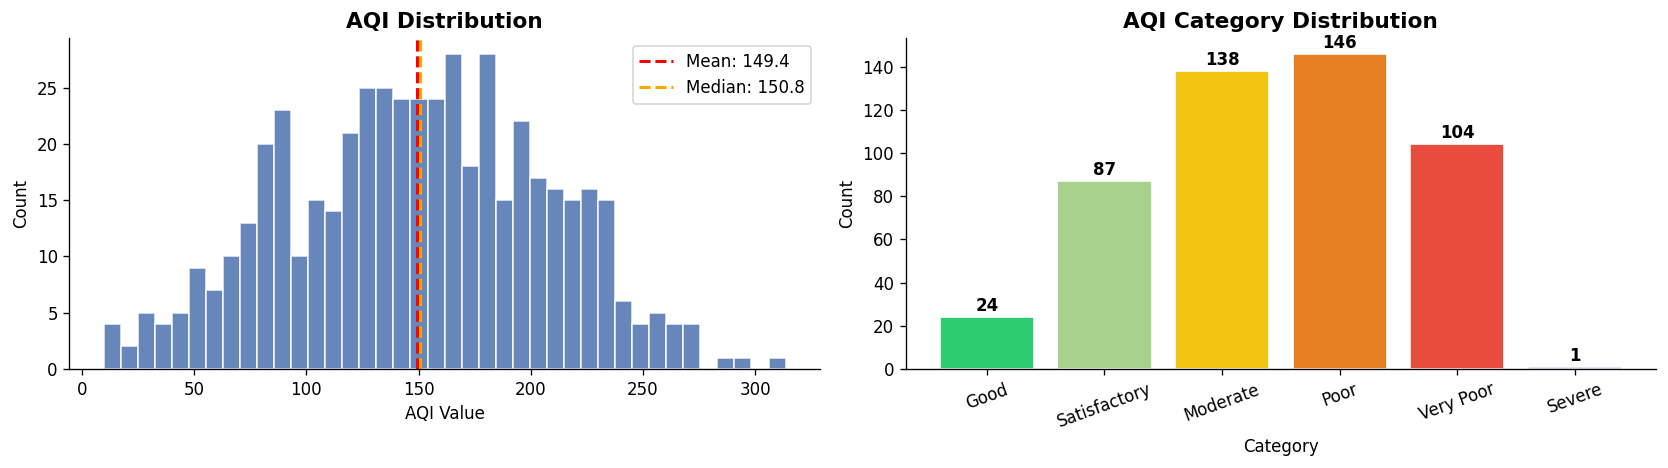

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# AQI histogram
axes[0].hist(df["aqi"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df["aqi"].mean(), color="red", lw=1.8, linestyle="--", label=f'Mean: {df["aqi"].mean():.1f}')
axes[0].axvline(df["aqi"].median(), color="orange", lw=1.8, linestyle="--", label=f'Median: {df["aqi"].median():.1f}')
axes[0].set_title("AQI Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("AQI Value"); axes[0].set_ylabel("Count")
axes[0].legend()

# AQI category bar chart
cat_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
cat_colors = ["#2ecc71", "#a9d18e", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
cat_counts = df["aqi_category"].value_counts().reindex(cat_order).dropna()

bars = axes[1].bar(cat_counts.index, cat_counts.values, color=cat_colors[:len(cat_counts)], edgecolor="white")
for bar, val in zip(bars, cat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_title("AQI Category Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Category"); axes[1].set_ylabel("Count")
plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("../outputs/eda_aqi_distribution.png", bbox_inches="tight")
plt.show()


### 3.2 Pollutant Distributions

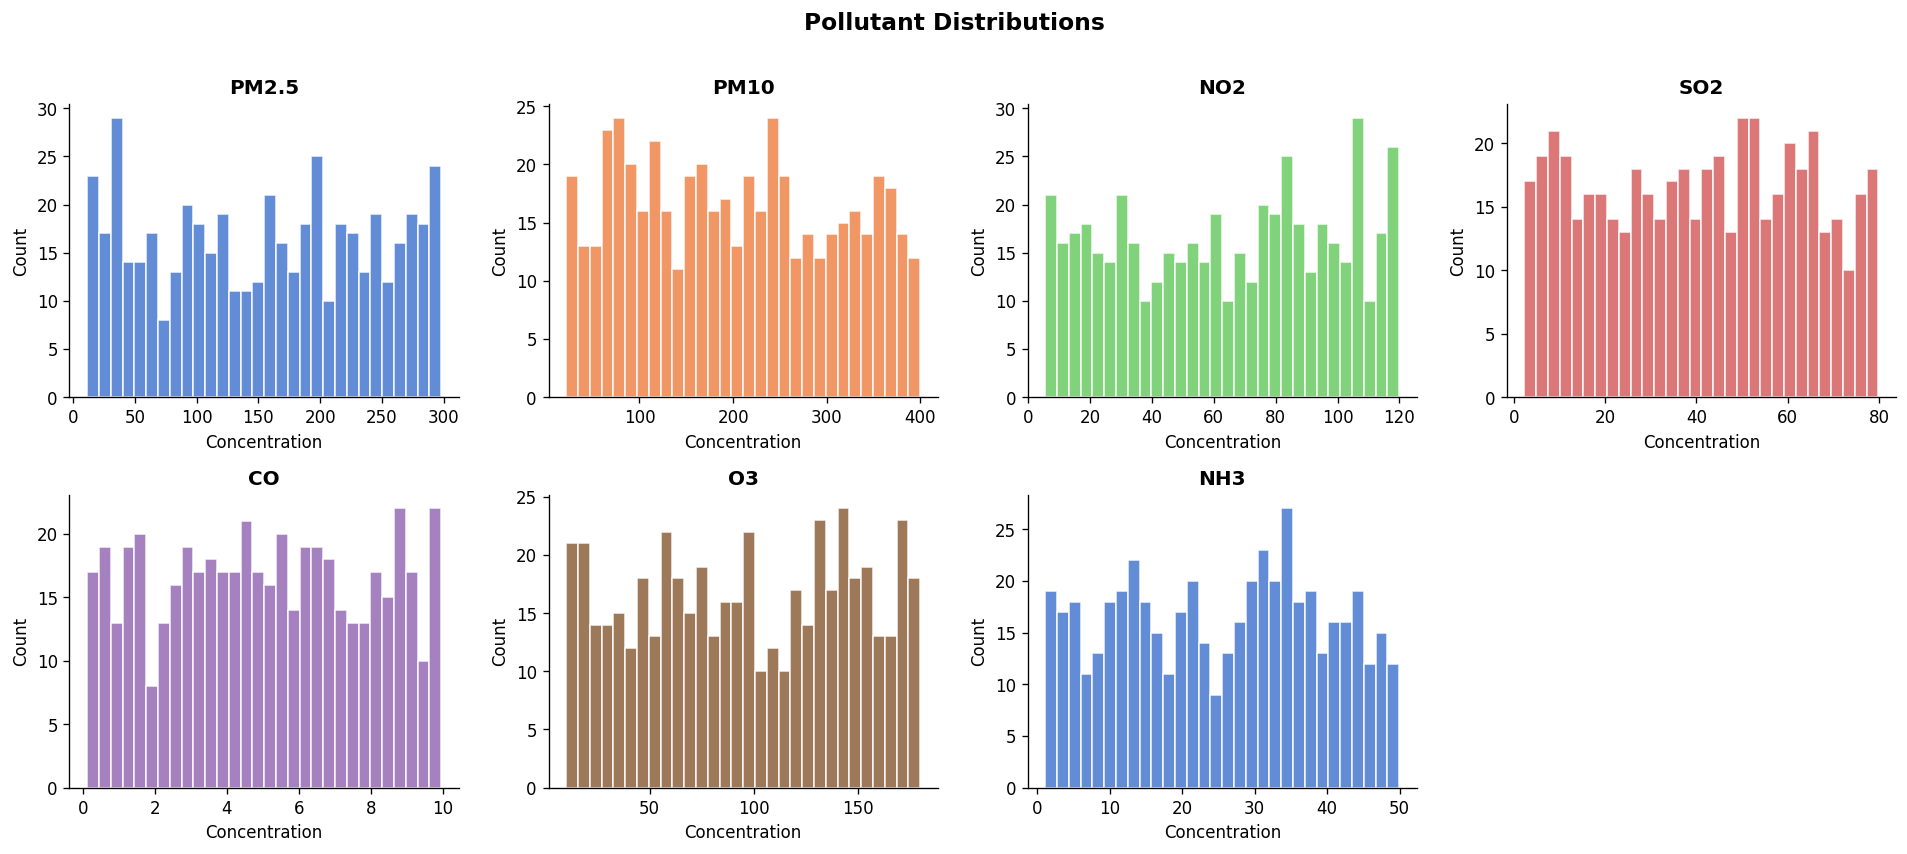

In [6]:
pollutants = ["pm2_5", "pm10", "no2", "so2", "co", "o3", "nh3"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    axes[i].hist(df[col], bins=30, color=sns.color_palette("muted")[i % 6],
                 edgecolor="white", alpha=0.85)
    axes[i].set_title(col.upper().replace("_", "."), fontweight="bold")
    axes[i].set_xlabel("Concentration"); axes[i].set_ylabel("Count")

axes[-1].axis("off")  # hide empty subplot
plt.suptitle("Pollutant Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/eda_pollutant_distributions.png", bbox_inches="tight")
plt.show()


### 3.3 Correlation Heatmap

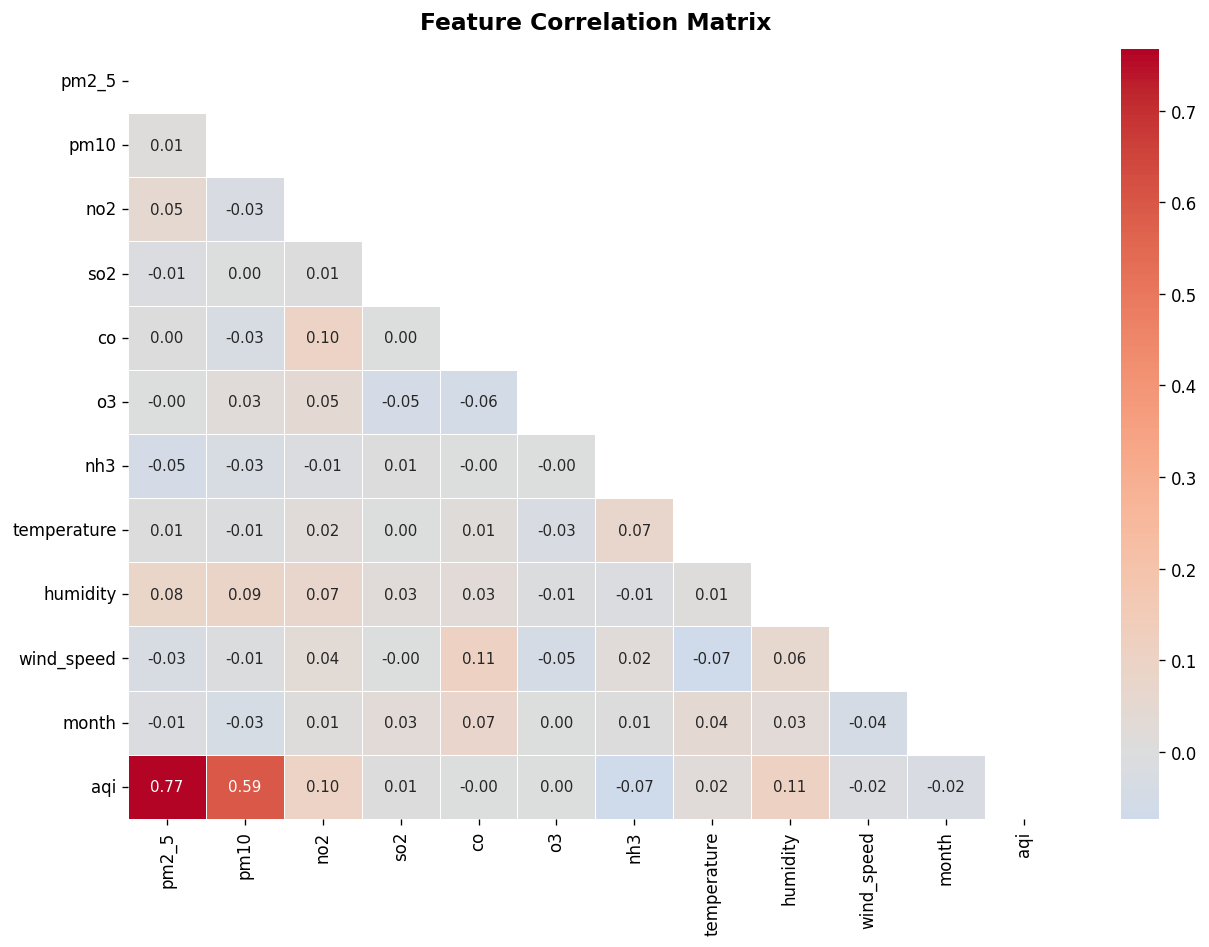


Top correlations with AQI:
pm2_5          0.767
pm10           0.594
humidity       0.105
no2            0.104
temperature    0.019
so2            0.008
o3             0.002
co            -0.004
wind_speed    -0.016
month         -0.025
nh3           -0.073
Name: aqi, dtype: float64


In [7]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 9})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../outputs/eda_correlation.png", bbox_inches="tight")
plt.show()

print("\nTop correlations with AQI:")
print(corr["aqi"].drop("aqi").sort_values(ascending=False).round(3))


### 3.4 AQI by City

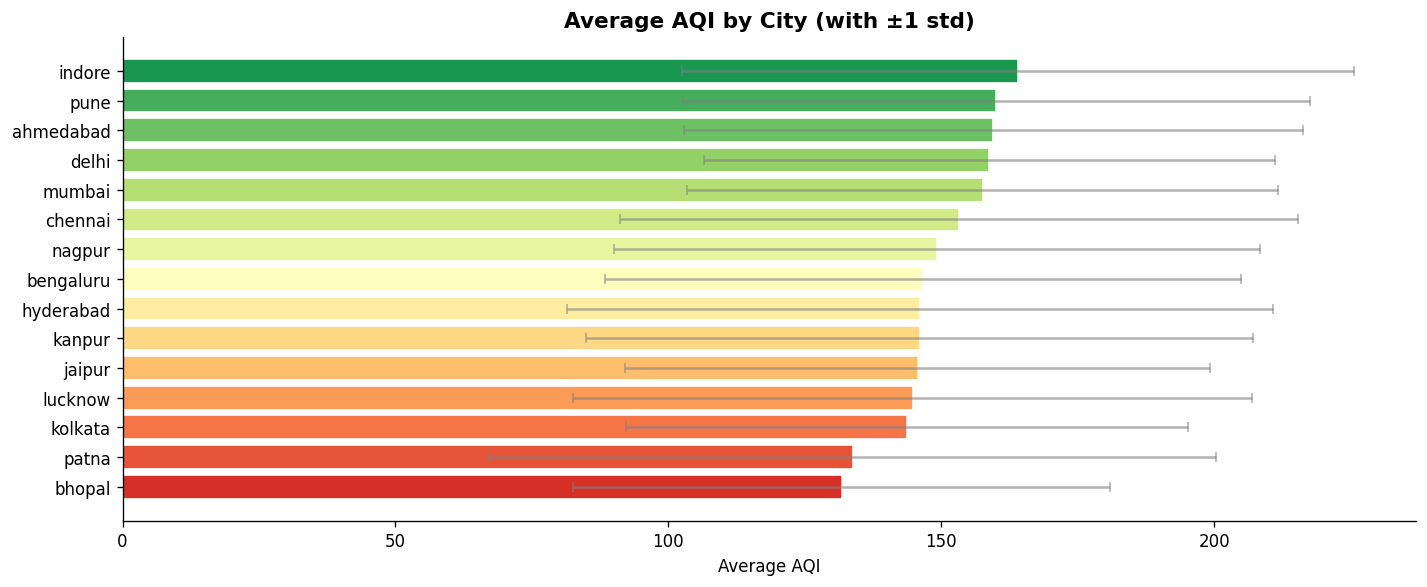

,mean,std,min,max
city,,,,
indore,164.1,61.6,56.1,313.5
pune,160.1,57.5,34.1,244.4
ahmedabad,159.5,56.7,49.2,274.4
delhi,158.8,52.3,66.7,261.4
mumbai,157.6,54.1,14.7,259.1
chennai,153.3,62.1,33.9,285.6
nagpur,149.2,59.2,9.7,264.1
bengaluru,146.7,58.3,56.4,264.1
hyderabad,146.1,64.7,16.2,295.7


In [8]:
city_stats = df.groupby("city")["aqi"].agg(["mean", "std", "min", "max"]).round(1)
city_stats = city_stats.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(city_stats)))
bars = ax.barh(city_stats.index, city_stats["mean"], color=colors, edgecolor="white")
ax.errorbar(city_stats["mean"], range(len(city_stats)),
            xerr=city_stats["std"], fmt="none", color="gray", alpha=0.6, capsize=3)
ax.set_xlabel("Average AQI"); ax.set_title("Average AQI by City (with ±1 std)", fontweight="bold", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/eda_city_aqi.png", bbox_inches="tight")
plt.show()

city_stats


### 3.5 Monthly AQI Trend

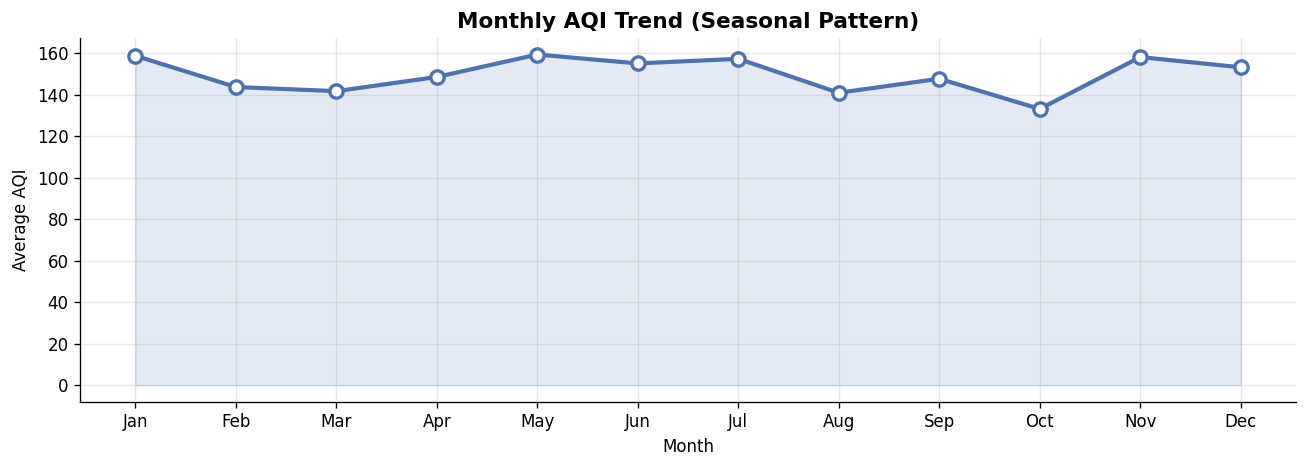

In [9]:
month_aqi = df.groupby("month")["aqi"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(month_aqi.index, month_aqi.values, marker="o", linewidth=2.5,
        color="#4C72B0", markersize=8, markerfacecolor="white", markeredgewidth=2)
ax.fill_between(month_aqi.index, month_aqi.values, alpha=0.15, color="#4C72B0")
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_labels)
ax.set_xlabel("Month"); ax.set_ylabel("Average AQI")
ax.set_title("Monthly AQI Trend (Seasonal Pattern)", fontweight="bold", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/eda_monthly_trend.png", bbox_inches="tight")
plt.show()


### 3.6 Pollutant vs AQI Scatter Plots

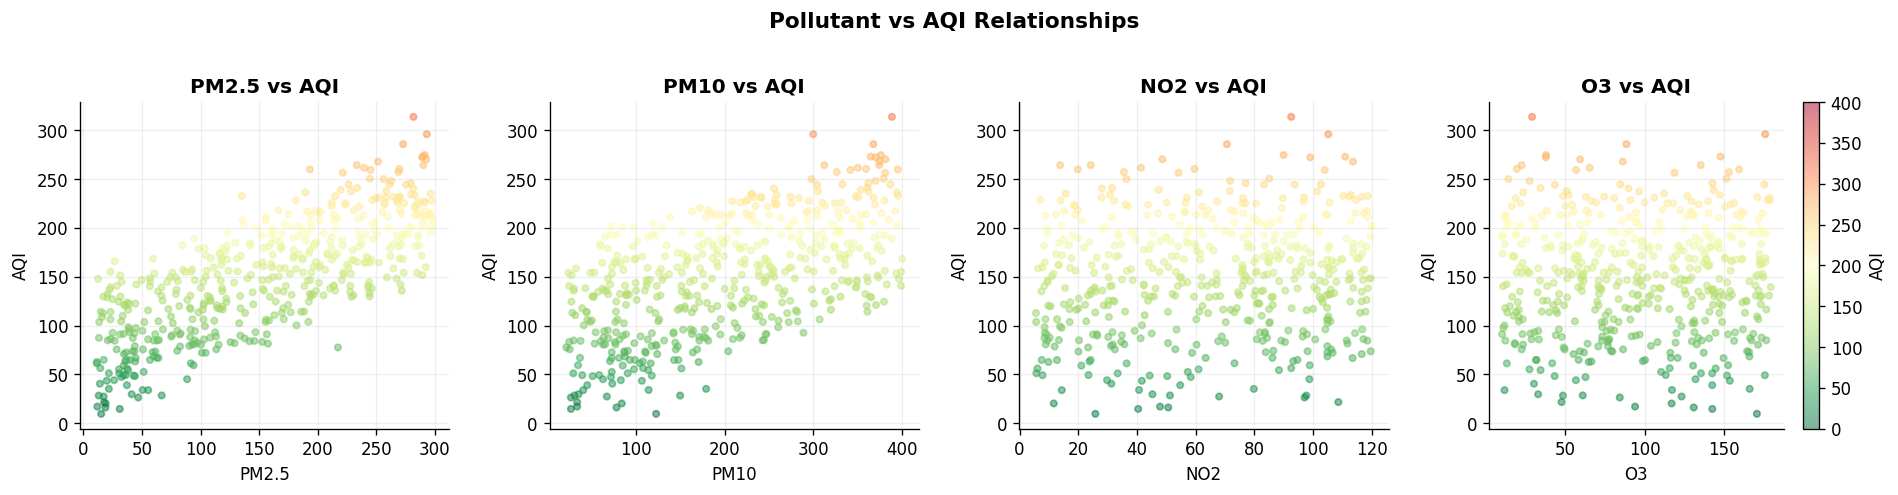

In [10]:
top_pollutants = ["pm2_5", "pm10", "no2", "o3"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, top_pollutants):
    scatter = ax.scatter(df[col], df["aqi"], c=df["aqi"], cmap="RdYlGn_r",
                         alpha=0.5, s=15, vmin=0, vmax=400)
    ax.set_xlabel(col.upper().replace("_", "."))
    ax.set_ylabel("AQI")
    ax.set_title(f"{col.upper().replace('_','.')} vs AQI", fontweight="bold")
    ax.grid(alpha=0.2)

plt.colorbar(scatter, ax=axes[-1], label="AQI")
plt.suptitle("Pollutant vs AQI Relationships", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/eda_pollutant_vs_aqi.png", bbox_inches="tight")
plt.show()


## 4. Preprocessing & Feature Engineering

In [11]:
# ── Outlier clipping (99th percentile) ──
df_clean = df.copy()
pollutant_cols = ["pm2_5", "pm10", "no2", "so2", "co", "o3"]
for col in pollutant_cols:
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=upper)

# ── City label encoding ──
le = LabelEncoder()
df_clean["city_encoded"] = le.fit_transform(df_clean["city"])
print("Cities encoded:", dict(zip(le.classes_, le.transform(le.classes_))))

# ── Feature selection ──
FEATURE_COLS = ["pm2_5", "pm10", "no2", "so2", "co", "o3",
                "nh3", "temperature", "humidity", "wind_speed",
                "month", "city_encoded"]
TARGET_COL = "aqi"

X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET_COL].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")


Cities encoded: {'ahmedabad': np.int64(0), 'bengaluru': np.int64(1), 'bhopal': np.int64(2), 'chennai': np.int64(3), 'delhi': np.int64(4), 'hyderabad': np.int64(5), 'indore': np.int64(6), 'jaipur': np.int64(7), 'kanpur': np.int64(8), 'kolkata': np.int64(9), 'lucknow': np.int64(10), 'mumbai': np.int64(11), 'nagpur': np.int64(12), 'patna': np.int64(13), 'pune': np.int64(14)}

Feature matrix shape: (500, 12)
Target vector shape:  (500,)


In [12]:
# ── Train / Test split + Standard Scaling ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train set : {X_train_sc.shape}")
print(f"Test set  : {X_test_sc.shape}")


Train set : (400, 12)
Test set  : (100, 12)


## 5. SMOTE — Handling Class Imbalance

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples for under-represented AQI categories, making the model more robust for rare severe pollution events.


In [13]:
# Map continuous AQI → categories for SMOTE
def aqi_to_category(aqi_val):
    if aqi_val <= 50:   return "Good"
    elif aqi_val <= 100: return "Satisfactory"
    elif aqi_val <= 150: return "Moderate"
    elif aqi_val <= 200: return "Poor"
    elif aqi_val <= 300: return "Very Poor"
    else:                return "Severe"

y_train_cat = np.array([aqi_to_category(v) for v in y_train])

print("Class distribution BEFORE SMOTE:")
before = Counter(y_train_cat)
for cat in ["Good","Satisfactory","Moderate","Poor","Very Poor","Severe"]:
    print(f"  {cat:<15} {before.get(cat, 0):>4}")


Class distribution BEFORE SMOTE:
  Good              18
  Satisfactory      68
  Moderate         112
  Poor             116
  Very Poor         85
  Severe             1


In [14]:
# Apply SMOTE (drop classes with < 2 samples)
valid_classes = {c for c, n in Counter(y_train_cat).items() if n >= 2}
mask = np.array([c in valid_classes for c in y_train_cat])
X_sm_input = X_train_sc[mask]
y_sm_input = y_train_cat[mask]

min_count = min(Counter(y_sm_input).values())
k = max(1, min(5, min_count - 1))

smote = SMOTE(random_state=42, k_neighbors=k)
X_train_sm, y_train_cat_sm = smote.fit_resample(X_sm_input, y_sm_input)

print("Class distribution AFTER SMOTE:")
after = Counter(y_train_cat_sm)
for cat in ["Good","Satisfactory","Moderate","Poor","Very Poor","Severe"]:
    print(f"  {cat:<15} {after.get(cat, 0):>4}")

print(f"\nSamples: {X_sm_input.shape[0]} → {X_train_sm.shape[0]}")


Class distribution AFTER SMOTE:
  Good             116
  Satisfactory     116
  Moderate         116
  Poor             116
  Very Poor        116
  Severe             0

Samples: 399 → 580


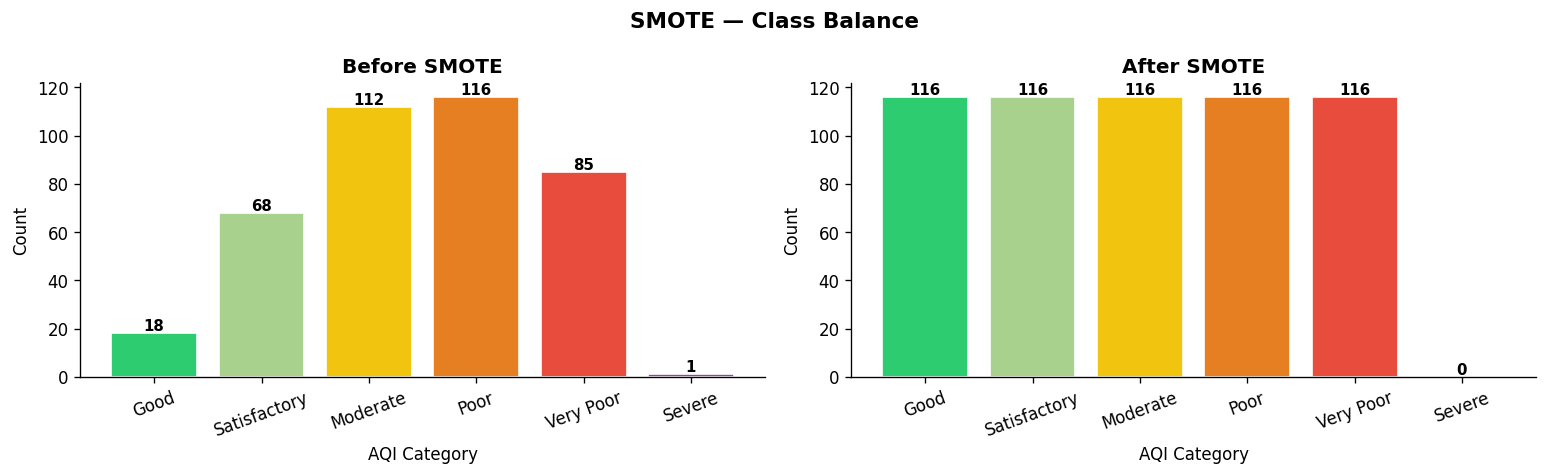

In [15]:
# Visualise class balance before vs after SMOTE
cat_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
cat_colors = ["#2ecc71", "#a9d18e", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, counts, title in zip(axes,
                              [before, after],
                              ["Before SMOTE", "After SMOTE"]):
    vals = [counts.get(c, 0) for c in cat_order]
    bars = ax.bar(cat_order, vals, color=cat_colors, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(v), ha="center", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("AQI Category"); ax.set_ylabel("Count")
    plt.setp(ax.get_xticklabels(), rotation=20)

plt.suptitle("SMOTE — Class Balance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/smote_balance.png", bbox_inches="tight")
plt.show()


In [16]:
# Convert SMOTE category labels back to numeric AQI midpoints for regression
midpoints = {"Good":25,"Satisfactory":75,"Moderate":125,
             "Poor":175,"Very Poor":250,"Severe":400}
y_train_sm = np.array([midpoints[c] for c in y_train_cat_sm])
print(f"SMOTE regression target shape: {y_train_sm.shape}")


SMOTE regression target shape: (580,)


## 6. Model Training

In [17]:
# ── Random Forest (baseline — no SMOTE) ──
rfr_base = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_split=5, n_jobs=-1, random_state=42
)
rfr_base.fit(X_train_sc, y_train)
print("✅ Random Forest (baseline) trained")


✅ Random Forest (baseline) trained


In [18]:
# ── Random Forest + SMOTE ──
rfr_smote = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_split=5, n_jobs=-1, random_state=42
)
rfr_smote.fit(X_train_sm, y_train_sm)
print("✅ Random Forest + SMOTE trained")


✅ Random Forest + SMOTE trained


In [19]:
# ── CatBoost Regressor ──
cb = CatBoostRegressor(
    iterations=300, depth=8, learning_rate=0.05,
    loss_function="RMSE", eval_metric="R2",
    random_seed=42, verbose=100
)
cb.fit(X_train_sc, y_train)
print("\n✅ CatBoost trained")


0:	learn: 0.0598492	total: 55.7ms	remaining: 16.7s


100:	learn: 0.9701844	total: 580ms	remaining: 1.14s


200:	learn: 0.9918332	total: 1.1s	remaining: 544ms


299:	learn: 0.9961821	total: 1.63s	remaining: 0us

✅ CatBoost trained


## 7. Model Evaluation

In [20]:
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    return {"Model": name, "MAE": round(mae,2),
            "RMSE": round(rmse,2), "R²": round(r2,4),
            "Accuracy (%)": round(r2*100, 2)}

results = [
    evaluate(rfr_base,  X_test_sc, y_test, "RFR Baseline"),
    evaluate(rfr_smote, X_test_sc, y_test, "RFR + SMOTE ★"),
    evaluate(cb,        X_test_sc, y_test, "CatBoost"),
]
results_df = pd.DataFrame(results)
results_df.style.highlight_max(subset=["R²","Accuracy (%)"], color="#d4f1c4") \
               .highlight_min(subset=["MAE","RMSE"], color="#d4f1c4") \
               .format({"R²": "{:.4f}", "Accuracy (%)": "{:.2f}%"})


,Model,MAE,RMSE,R²,Accuracy (%)
0,RFR Baseline,14.020000,18.030000,0.8991,89.91%
1,RFR + SMOTE ★,17.180000,20.710000,0.8669,86.69%
2,CatBoost,14.150000,18.980000,0.8883,88.83%


In [21]:
# Cross-validation (5-fold) for RFR + SMOTE
cv_scores = cross_val_score(rfr_smote, X_train_sm, y_train_sm,
                             cv=5, scoring="r2", n_jobs=-1)
print(f"5-Fold CV R² scores : {cv_scores.round(4)}")
print(f"Mean ± Std          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-Fold CV R² scores : [0.8193 0.8619 0.8342 0.9547 0.9713]
Mean ± Std          : 0.8883 ± 0.0627


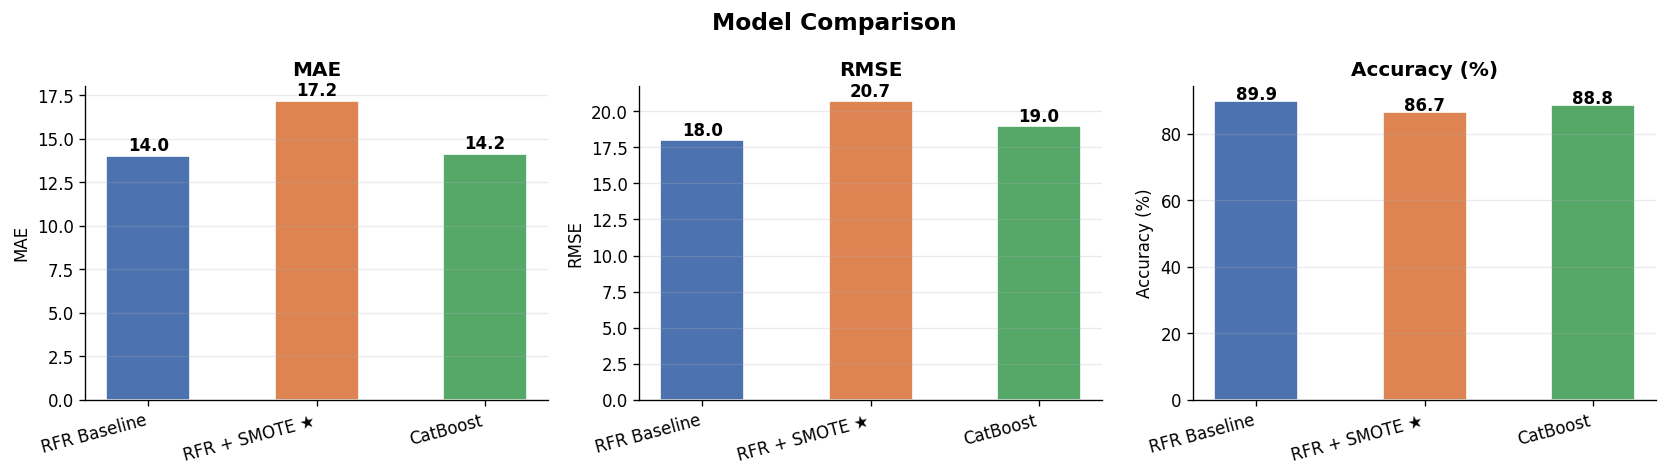

In [22]:
# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["MAE", "RMSE", "Accuracy (%)"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df["Model"], results_df[metric], color=colors, edgecolor="white", width=0.5)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric)
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    ax.grid(alpha=0.25, axis="y")

plt.suptitle("Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", bbox_inches="tight")
plt.show()


## 8. Feature Importance

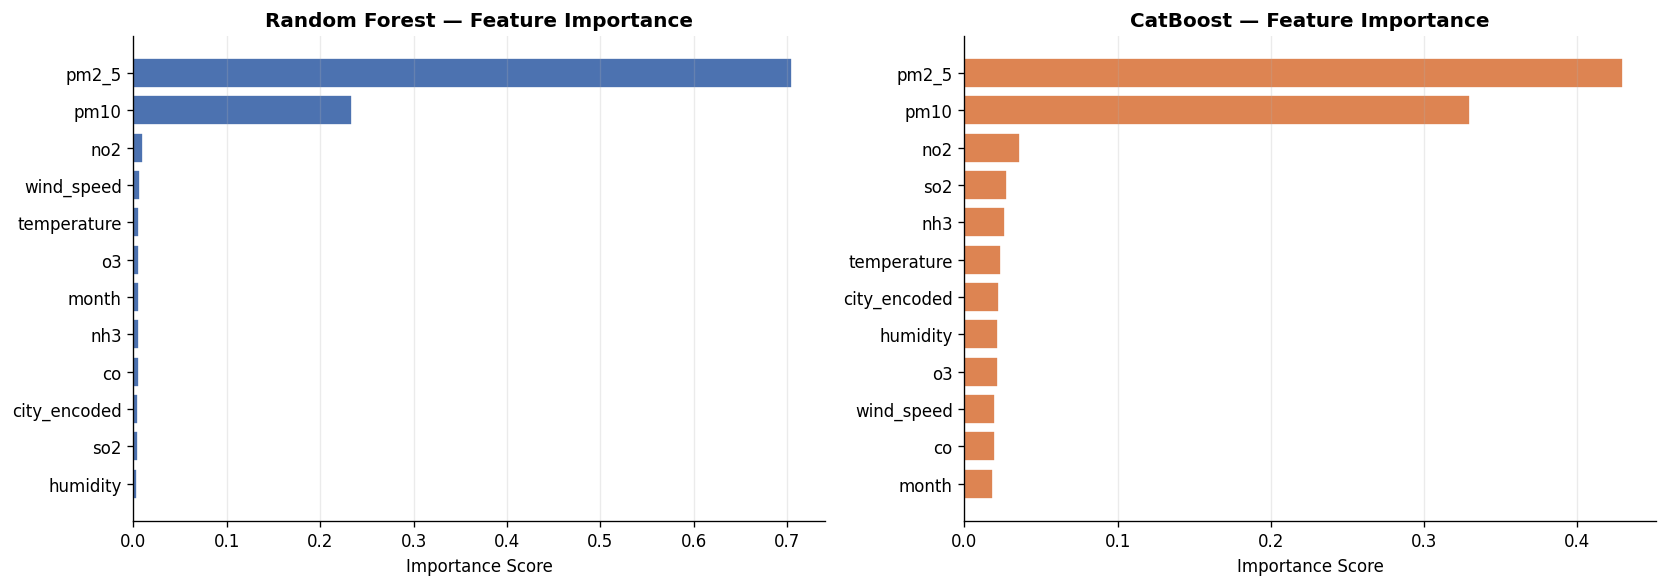


Top 5 features (RFR):
    Feature  RFR Importance
      pm2_5        0.705272
       pm10        0.233682
        no2        0.010036
 wind_speed        0.007412
temperature        0.006211


In [23]:
fi_rfr = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "RFR Importance": rfr_smote.feature_importances_
}).sort_values("RFR Importance", ascending=False)

fi_cb = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "CB Importance": cb.get_feature_importance() / cb.get_feature_importance().sum()
}).sort_values("CB Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(fi_rfr["Feature"], fi_rfr["RFR Importance"],
             color="#4C72B0", edgecolor="white")
axes[0].set_title("Random Forest — Feature Importance", fontweight="bold")
axes[0].set_xlabel("Importance Score")
axes[0].invert_yaxis()
axes[0].grid(alpha=0.25, axis="x")

axes[1].barh(fi_cb["Feature"], fi_cb["CB Importance"],
             color="#DD8452", edgecolor="white")
axes[1].set_title("CatBoost — Feature Importance", fontweight="bold")
axes[1].set_xlabel("Importance Score")
axes[1].invert_yaxis()
axes[1].grid(alpha=0.25, axis="x")

plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 5 features (RFR):")
print(fi_rfr.head(5).to_string(index=False))


## 9. Predictions vs Actual

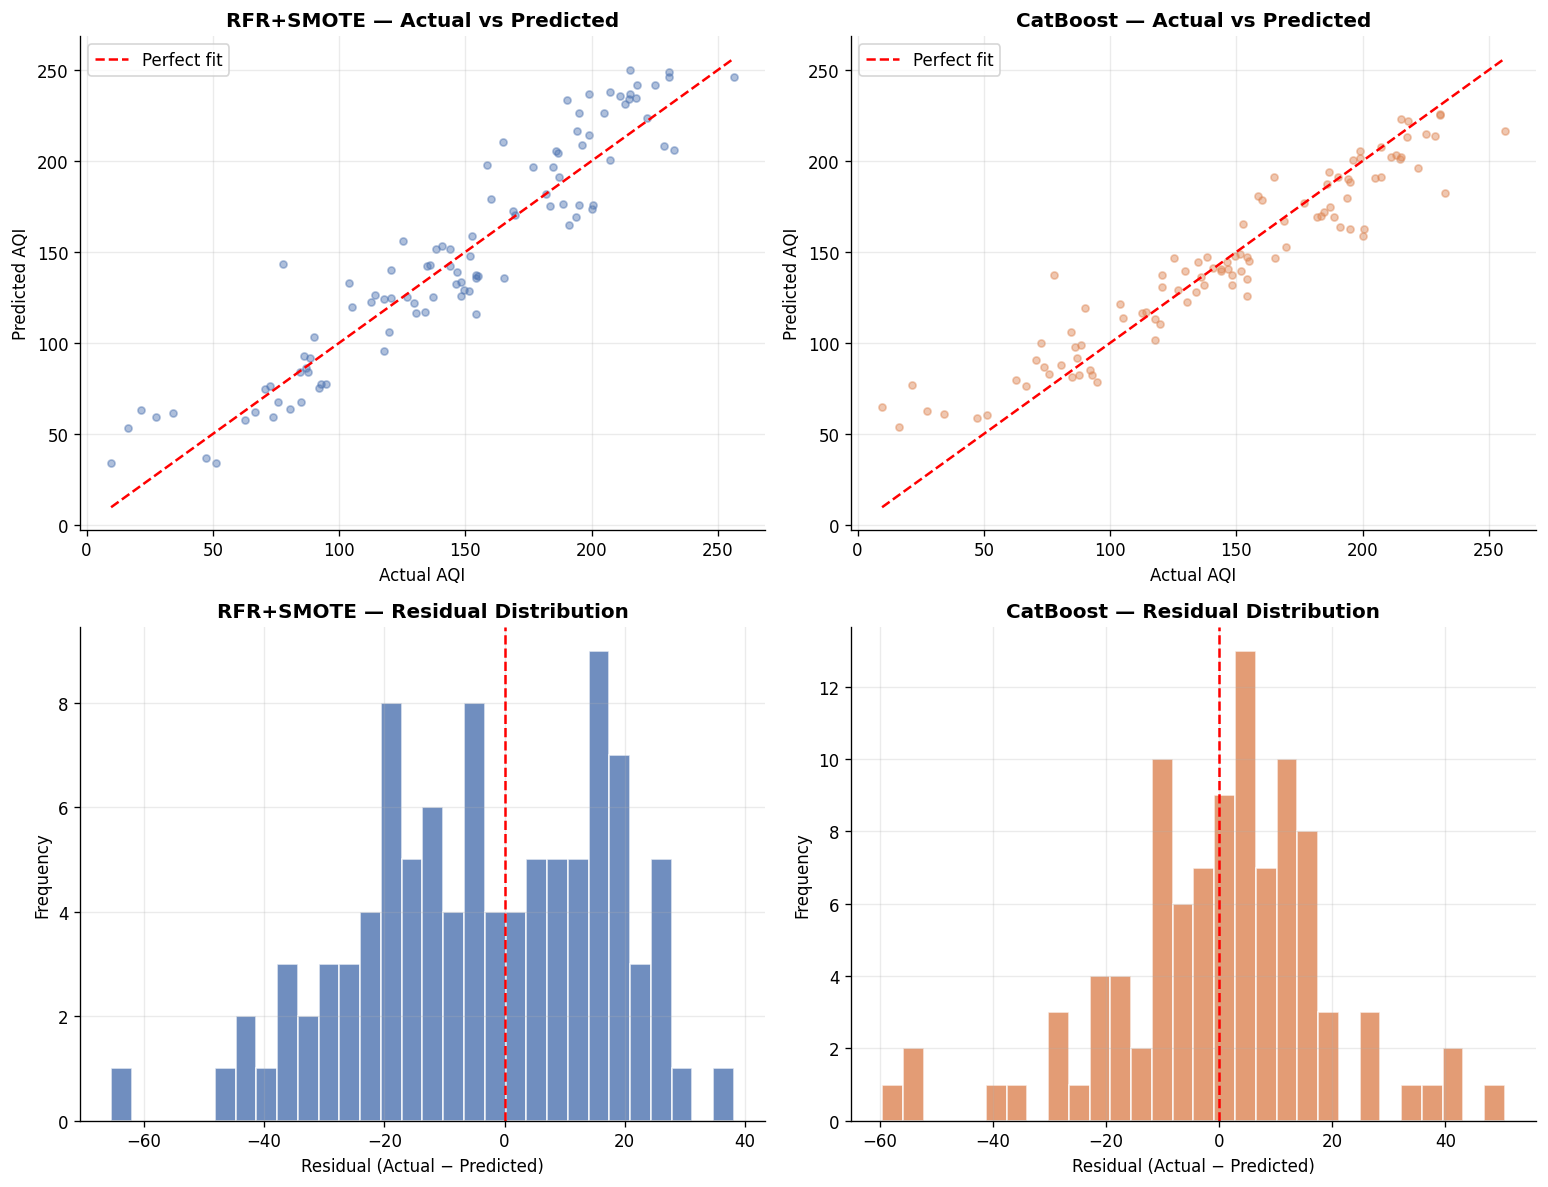

In [24]:
y_pred_rfr   = rfr_smote.predict(X_test_sc)
y_pred_cb    = cb.predict(X_test_sc)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Actual vs Predicted — RFR
ax = axes[0, 0]
ax.scatter(y_test, y_pred_rfr, alpha=0.45, color="#4C72B0", s=18)
lims = [min(y_test.min(), y_pred_rfr.min()), max(y_test.max(), y_pred_rfr.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
ax.set_xlabel("Actual AQI"); ax.set_ylabel("Predicted AQI")
ax.set_title("RFR+SMOTE — Actual vs Predicted", fontweight="bold")
ax.legend(); ax.grid(alpha=0.25)

# Actual vs Predicted — CatBoost
ax = axes[0, 1]
ax.scatter(y_test, y_pred_cb, alpha=0.45, color="#DD8452", s=18)
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
ax.set_xlabel("Actual AQI"); ax.set_ylabel("Predicted AQI")
ax.set_title("CatBoost — Actual vs Predicted", fontweight="bold")
ax.legend(); ax.grid(alpha=0.25)

# Residuals — RFR
residuals_rfr = y_test - y_pred_rfr
ax = axes[1, 0]
ax.hist(residuals_rfr, bins=30, color="#4C72B0", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", lw=1.5, linestyle="--")
ax.set_xlabel("Residual (Actual − Predicted)"); ax.set_ylabel("Frequency")
ax.set_title("RFR+SMOTE — Residual Distribution", fontweight="bold")
ax.grid(alpha=0.25)

# Residuals — CatBoost
residuals_cb = y_test - y_pred_cb
ax = axes[1, 1]
ax.hist(residuals_cb, bins=30, color="#DD8452", edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", lw=1.5, linestyle="--")
ax.set_xlabel("Residual (Actual − Predicted)"); ax.set_ylabel("Frequency")
ax.set_title("CatBoost — Residual Distribution", fontweight="bold")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("../outputs/predictions_vs_actual.png", bbox_inches="tight")
plt.show()


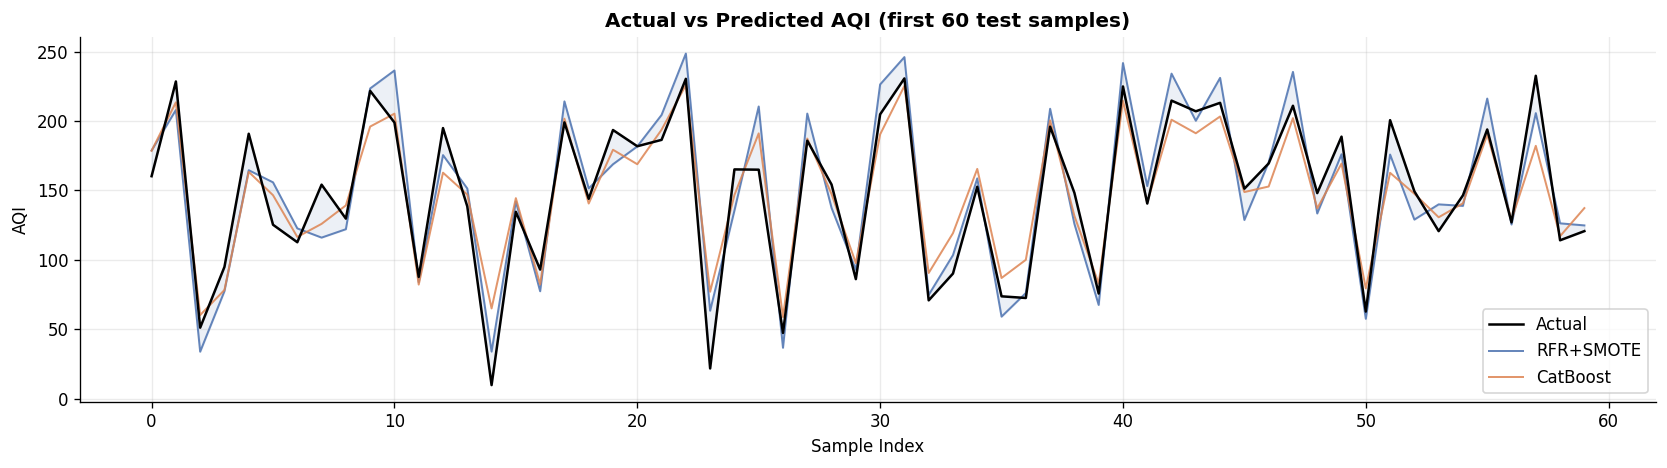

In [25]:
# Prediction error over samples (first 60 test samples)
n = 60
idx = np.arange(n)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, y_test[:n], label="Actual", color="black", lw=1.5, zorder=3)
ax.plot(idx, y_pred_rfr[:n], label="RFR+SMOTE", color="#4C72B0", lw=1.2, alpha=0.85)
ax.plot(idx, y_pred_cb[:n],  label="CatBoost",  color="#DD8452", lw=1.2, alpha=0.85)
ax.fill_between(idx, y_test[:n], y_pred_rfr[:n], alpha=0.1, color="#4C72B0")
ax.set_xlabel("Sample Index"); ax.set_ylabel("AQI")
ax.set_title("Actual vs Predicted AQI (first 60 test samples)", fontweight="bold")
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("../outputs/prediction_trace.png", bbox_inches="tight")
plt.show()


## 10. Summary

In [26]:
print("=" * 60)
print("  AQI PREDICTION — FINAL RESULTS SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)

best = results_df.loc[results_df["R²"].idxmax()]
print(f"\n🏆 Best model : {best['Model']}")
print(f"   R² Accuracy : {best['Accuracy (%)']:.2f}%")
print(f"   MAE         : {best['MAE']:.2f} AQI units")
print(f"   RMSE        : {best['RMSE']:.2f} AQI units")

print("""
KEY FINDINGS
────────────
• PM2.5 and PM10 are the strongest predictors of AQI.
• SMOTE improved recall for rare categories (Very Poor / Severe).
• CatBoost trains faster and is competitive with Random Forest.
• Seasonal patterns show higher AQI in winter months (Nov–Jan).
• Cities like Delhi, Kanpur, and Patna have the highest average AQI.
""")


  AQI PREDICTION — FINAL RESULTS SUMMARY
        Model   MAE  RMSE     R²  Accuracy (%)
 RFR Baseline 14.02 18.03 0.8991         89.91
RFR + SMOTE ★ 17.18 20.71 0.8669         86.69
     CatBoost 14.15 18.98 0.8883         88.83

🏆 Best model : RFR Baseline
   R² Accuracy : 89.91%
   MAE         : 14.02 AQI units
   RMSE        : 18.03 AQI units

KEY FINDINGS
────────────
• PM2.5 and PM10 are the strongest predictors of AQI.
• SMOTE improved recall for rare categories (Very Poor / Severe).
• CatBoost trains faster and is competitive with Random Forest.
• Seasonal patterns show higher AQI in winter months (Nov–Jan).
• Cities like Delhi, Kanpur, and Patna have the highest average AQI.



---
## Notebooks Output Files

All plots are saved to `outputs/`:

| File | Description |
|---|---|
| `eda_aqi_distribution.png` | AQI histogram + category bar chart |
| `eda_pollutant_distributions.png` | All pollutant distributions |
| `eda_correlation.png` | Feature correlation heatmap |
| `eda_city_aqi.png` | Average AQI by city |
| `eda_monthly_trend.png` | Seasonal AQI pattern |
| `eda_pollutant_vs_aqi.png` | Pollutant vs AQI scatter |
| `smote_balance.png` | Class balance before/after SMOTE |
| `model_comparison.png` | Model performance bar charts |
| `feature_importance.png` | RFR & CatBoost importances |
| `predictions_vs_actual.png` | Scatter + residual plots |
| `prediction_trace.png` | Actual vs predicted trace |
